<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967%2C8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота №7,8. Чуркін Дмитро, ФІТ 3-15

Був присутній на парі

In [2]:
!pip install mesa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 9.5 MB/s eta 0:00:00


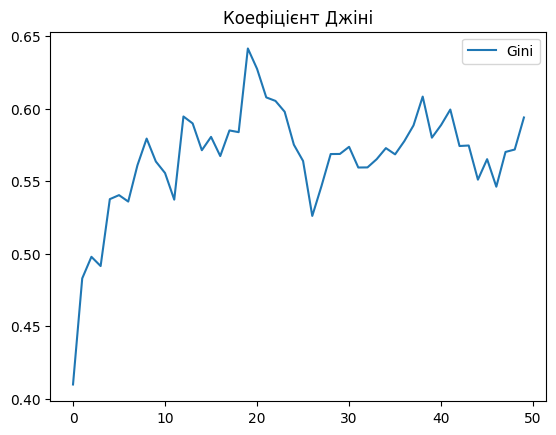

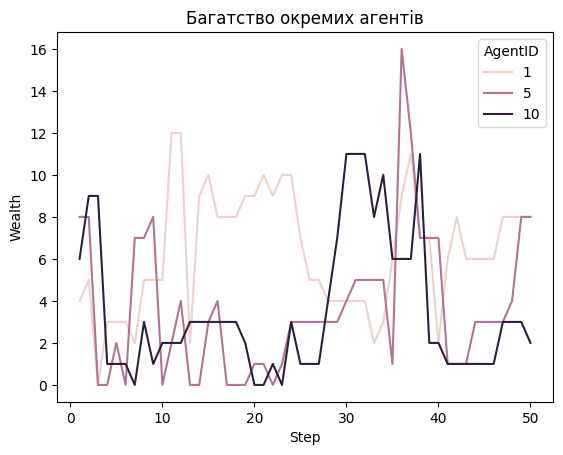

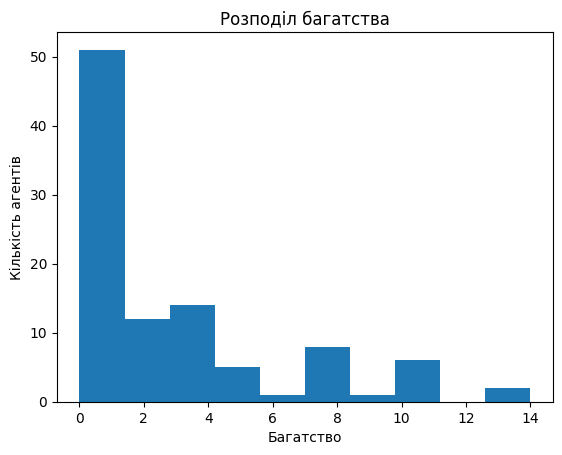

In [3]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector

# --- GINI ---
def compute_gini(model):
    wealths = [agent.wealth for agent in model.agents]
    n = len(wealths)
    mean = np.mean(wealths)
    if mean == 0:
        return 0
    diff_sum = sum(abs(x - y) for x in wealths for y in wealths)
    return diff_sum / (2 * n**2 * mean)

# --- АГЕНТ ---
class MoneyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        # випадкове початкове багатство
        self.wealth = self.random.randint(1, 5)

    def move(self):
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def give_money(self):
        if self.wealth > 0:
            cellmates = self.model.grid.get_cell_list_contents([self.pos])
            cellmates = [a for a in cellmates if a != self]

            if len(cellmates) > 0:
                other = self.random.choice(cellmates)

                # випадковий обмін
                amount = self.random.randint(1, self.wealth)
                other.wealth += amount
                self.wealth -= amount

# --- МОДЕЛЬ ---
class MoneyModel(mesa.Model):
    def __init__(self, n, width, height):
        super().__init__()
        self.num_agents = n
        self.grid = MultiGrid(width, height, True)

        agents = MoneyAgent.create_agents(model=self, n=n)

        for agent in agents:
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            self.grid.place_agent(agent, (x, y))

        self.datacollector = DataCollector(
            model_reporters={"Gini": compute_gini},
            agent_reporters={"Wealth": "wealth"}
        )

    def step(self):
        self.agents.shuffle_do("move")
        self.agents.do("give_money")
        self.datacollector.collect(self)

# --- ЗАПУСК МОДЕЛІ ---
model = MoneyModel(n=100, width=10, height=10)

steps = 50
for i in range(steps):
    model.step()

# --- ГРАФІК GINI ---
gini = model.datacollector.get_model_vars_dataframe()
sns.lineplot(data=gini)
plt.title("Коефіцієнт Джіні")
plt.show()

# --- ГРАФІК БАГАТСТВА 3 АГЕНТІВ ---
agent_wealth = model.datacollector.get_agent_vars_dataframe()

agents_to_plot = [1, 5, 10]

data = agent_wealth[
    agent_wealth.index.get_level_values("AgentID").isin(agents_to_plot)
]

sns.lineplot(data=data, x="Step", y="Wealth", hue="AgentID")
plt.title("Багатство окремих агентів")
plt.show()

# --- ГІСТОГРАМА РОЗПОДІЛУ ---
final_wealth = [a.wealth for a in model.agents]

plt.hist(final_wealth, bins=10)
plt.title("Розподіл багатства")
plt.xlabel("Багатство")
plt.ylabel("Кількість агентів")
plt.show()

Етап 8

/tmp/ipykernel_5034/1122688134.py:42: DeprecationWarning: The `iterations` keyword argument is deprecated. Use `rng` instead (e.g. `iterations=5` is equivalent to `rng=[None] * 5`). See https://mesa.readthedocs.io/latest/migration_guide.html#batch-run
  results = batch_run(


  0%|          | 0/500 [00:00<?, ?it/s]

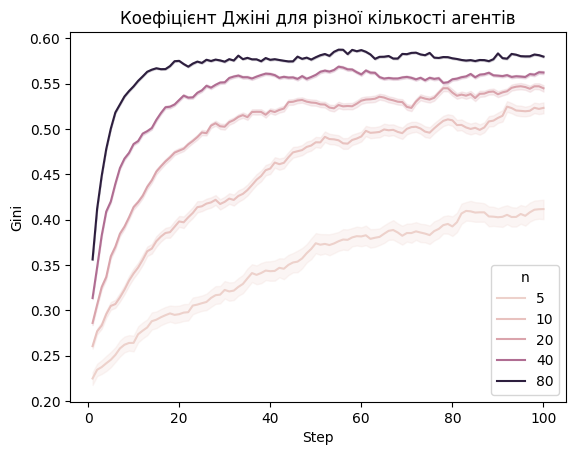

In [5]:
from mesa.batchrunner import batch_run
class MoneyModel(mesa.Model):
    def __init__(self, n, width, height, rng=None):
        super().__init__(rng=rng)

        self.num_agents = n
        self.grid = mesa.space.MultiGrid(width, height, True)

        # DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini},
            agent_reporters={"Wealth": "wealth"}
        )

        # Створення агентів
        agents = MoneyAgent.create_agents(model=self, n=n)

        # Випадкові координати
        x = self.rng.integers(0, self.grid.width, size=n)
        y = self.rng.integers(0, self.grid.height, size=n)

        for a, i, j in zip(agents, x, y):
            self.grid.place_agent(a, (i, j))

        self.running = True

    def step(self):
        self.agents.shuffle_do("move")
        self.agents.do("give_money")
        self.datacollector.collect(self)
from mesa.batchrunner import batch_run
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

params = {
    "width": 10,
    "height": 10,
    "n": [5, 10, 20, 40, 80]
}

results = batch_run(
    MoneyModel,
    parameters=params,
    iterations=100,
    max_steps=100,
    data_collection_period=1,
    number_processes=1
)

results_df = pd.DataFrame(results)

sns.lineplot(
    data=results_df,
    x="Step",
    y="Gini",
    hue="n",
    errorbar=("ci", 95)
)

plt.title("Коефіцієнт Джіні для різної кількості агентів")
plt.show()